In [1]:
import pyedflib as edf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
reader = edf.EdfReader("data/sracka.edf")

reader.getSignalLabels()

['Abdomen CaL',
 'Abdomen Fast',
 'Abdomen',
 'Activity',
 'AF3',
 'AF3 Impedance',
 'AF3-E3 (Imp)',
 'AF3-E3E4',
 'AF4',
 'AF4 Impedance',
 'AF4-E3 (Imp)',
 'AF4-E3E4',
 'AF7',
 'AF7 Impedance',
 'AF7-E3 (Imp)',
 'AF7-E3E4',
 'AF8',
 'AF8 Impedance',
 'AF8-E3 (Imp)',
 'AF8-E3E4',
 'AFZ',
 'AFZ Impedance',
 'Light',
 'Audio',
 'Audio Volume',
 'Audio Volume dB',
 'cRIP Flow',
 'cRIP Sum',
 'E1',
 'E1 Impedance',
 'E1-E3 (Imp)',
 'E1-E4',
 'E2',
 'E2 Impedance',
 'E2-AFZ',
 'E2-AFZ (Imp)',
 'E2-E3',
 'E2-E4 (Imp)',
 'E3',
 'E3 Impedance',
 'E3-AFZ',
 'E3-AFZ (Imp)',
 'E3E4',
 'E4',
 'E4 Impedance',
 'ECG',
 'ECG Impedance',
 'ECG LA',
 'ECG LA Impedance',
 'ECG LF',
 'ECG LF Impedance',
 'ECG RA',
 'ECG RA Impedance',
 'Elevation',
 'EMG.Temporalis-L',
 'EMG.Temporalis-R',
 'Flow',
 'Flow Limitation',
 'Inductance Abdom',
 'Inductance Thora',
 'K',
 'LA-RA',
 'Left Leg',
 'Left Leg Impedan',
 'LF-LA',
 'LF-RA',
 'LF-RA (Imp)',
 'Nasal Pressure',
 'Pulse Waveform',
 'PosAngle',
 'Pulse',

Signal: E2-AFZ
Sample frequency: 200.0 Hz
Total samples available: 5396000
Duration: 26980.00 seconds


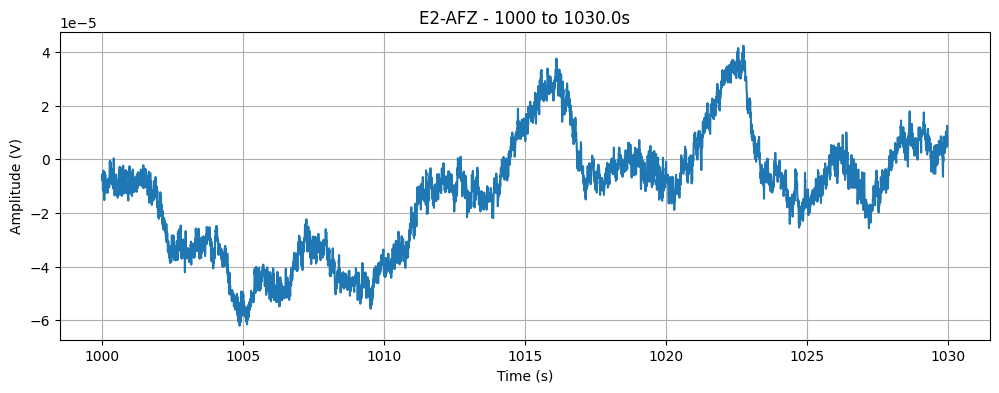

In [4]:
signal_name = "E2-AFZ"
start_sec = 1000

# Reopen the file with a fresh reader
with edf.EdfReader("data/sracka.edf") as f:
    # Find channel index by name  
    signal_labels = [label.upper() for label in f.getSignalLabels()]  
    try:  
        channel_idx = signal_labels.index(signal_name.upper())  
    except ValueError:  
        raise ValueError(f"Signal '{signal_name}' not found. Available signals: {f.getSignalLabels()}")  
        
    # Get signal info  
    fs = f.getSampleFrequency(channel_idx)  
    label = f.getLabel(channel_idx)
    n_samples_available = f.getNSamples()[channel_idx]

    print(f"Signal: {label}")
    print(f"Sample frequency: {fs} Hz")
    print(f"Total samples available: {n_samples_available}")
    print(f"Duration: {n_samples_available/fs:.2f} seconds")
        
    # Calculate sample indices for 30-second interval  
    start_sample = int(start_sec * fs)  
    n_samples = int(30 * fs)  # 30 seconds
    end_sample = start_sample + n_samples

    # Check bounds
    if start_sample >= n_samples_available:
        raise ValueError(f"Start time {start_sec}s exceeds signal duration")
    if end_sample > n_samples_available:
        print(f"Warning: Requested end exceeds signal. Adjusting to signal end.")
        end_sample = n_samples_available
        n_samples = end_sample - start_sample

    # Read the full signal and slice
    full_signal = f.readSignal(channel_idx)
    signal = full_signal[start_sample:end_sample]
    phys_dim = f.getPhysicalDimension(channel_idx)
    
# Create time axis  
time = np.arange(len(signal)) / fs + start_sec  
    
# Plot  
plt.figure(figsize=(12, 4))  
plt.plot(time, signal)  
plt.title(f'{label} - {start_sec} to {start_sec + len(signal)/fs:.1f}s')  
plt.xlabel('Time (s)')  
plt.ylabel(f'Amplitude ({phys_dim})')  
plt.grid(True)  
plt.show()

In [11]:
from math import e, pow

# W, R, N1, N2, N3
seen = [-5, -5, -6, -5, -5]
seen = [s + 5 for s in seen]
denom = sum([pow(e, s) for s in seen])
probs = [pow(e, s) / denom for s in seen]

probs

[0.22894404789977563,
 0.22894404789977563,
 0.08422380840089738,
 0.22894404789977563,
 0.22894404789977563]